# Chapter 3 — Classification

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                      StratifiedKFold, GridSearchCV, train_test_split)
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score,
                              precision_recall_curve, roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.base import BaseEstimator, TransformerMixin, clone

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

## MNIST

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [4]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

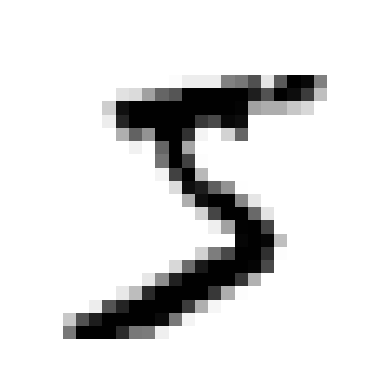

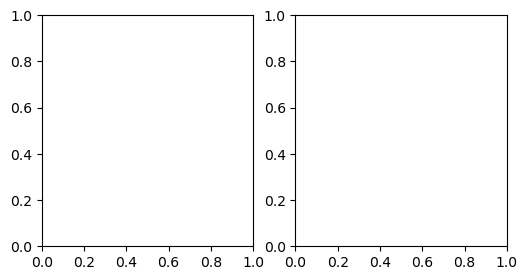

In [5]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()
fig, axs = plt.subplots(1, 2, figsize=(6, 3))


In [6]:
y[0]

'5'

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

In [8]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [113]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

sgd_clf.predict([some_digit])

KeyboardInterrupt: 

KeyboardInterrupt: 

## Performance Measures

### Measuring Accuracy Using Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

### Implementing Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is
# not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred)) # prints 0.95035, 0.96035, and 0.9604

0.95035
0.96035
0.9604


## Confusion Matrix

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, n_jobs=3)

In [ ]:
y_train_pred

array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [ ]:
y_train_perfect_prediction = y_train_5 # pretend we reached perfection
cm_perfect = confusion_matrix(y_train_5, y_train_perfect_prediction)
cm_perfect

array([[54579,     0],
       [    0,  5421]])

### Interpretación de la matriz de confusión (TN, FP, FN, TP)

Para clasificación binaria (aquí: **“es 5”** vs **“no es 5”**), la matriz sigue este orden en `sklearn`:

\[
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
\]

Con tu matriz `cm`:

\[
\begin{bmatrix}
53892 & 687 \\
1891 & 3530
\end{bmatrix}
\]

- **TN (True Negatives) = 53,892**  
    El modelo predijo **“no es 5”** y realmente **no era 5**.

- **FP (False Positives) = 687**  
    El modelo predijo **“es 5”**, pero en realidad **no era 5** (falsas alarmas).

- **FN (False Negatives) = 1,891**  
    El modelo predijo **“no es 5”**, pero en realidad **sí era 5** (5s que se escaparon).

- **TP (True Positives) = 3,530**  
    El modelo predijo **“es 5”** y realmente **sí era 5**.

---

**Resumen rápido:** tu clasificador comete más **FN** que **FP**, o sea, tiende más a perder algunos “5” reales que a inventar “5” donde no los hay.

## Precision and Recall

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred) 

0.8370879772350012

In [ ]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

## The Presicion/Recall Trade-Off

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [ ]:
trueshold = 0
y_some_digit_pred = (y_scores > trueshold)
y_some_digit_pred

array([ True])

In [ ]:
trueshold = 3000
y_some_digit_pred = (y_scores > trueshold)
y_some_digit_pred

array([False])

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function', n_jobs=3)
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [ ]:
from plotnine import * 

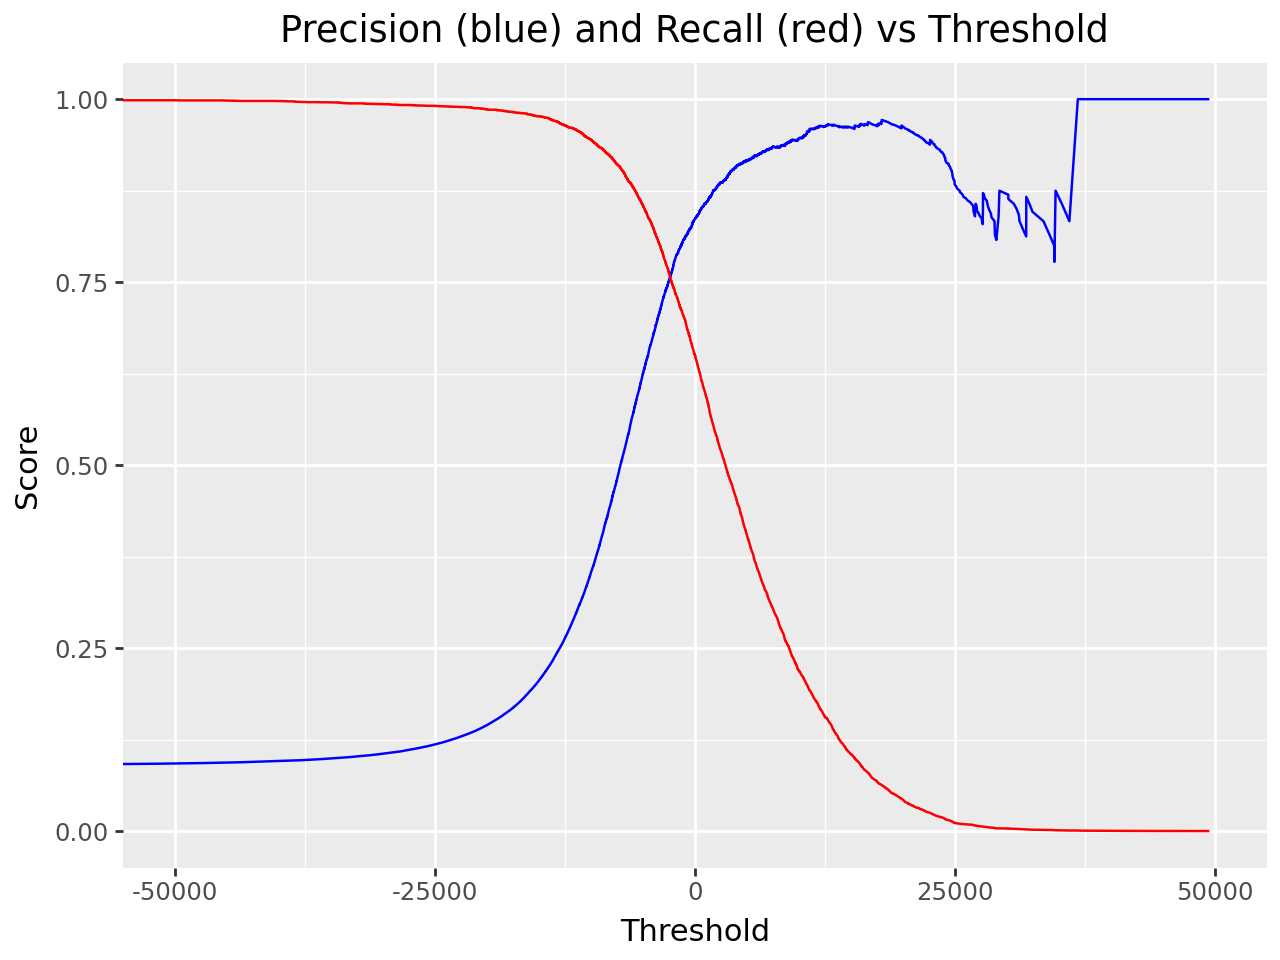

In [ ]:
# Plot precision and recall as a function of the threshold with plotnine
# (limited x-axis range from -5000 to 500)
(
    ggplot(
        data=pd.DataFrame({
            'thresholds': thresholds,
            'precisions': precisions[:-1],
            'recalls': recalls[:-1]
        })
    )
    + geom_line(aes(x='thresholds', y='precisions'), color='blue')
    + geom_line(aes(x='thresholds', y='recalls'), color='red')
    + coord_cartesian(xlim=(-50000, 50000))
    + labs(
        x='Threshold',
        y='Score',
        title='Precision (blue) and Recall (red) vs Threshold'
    )
)

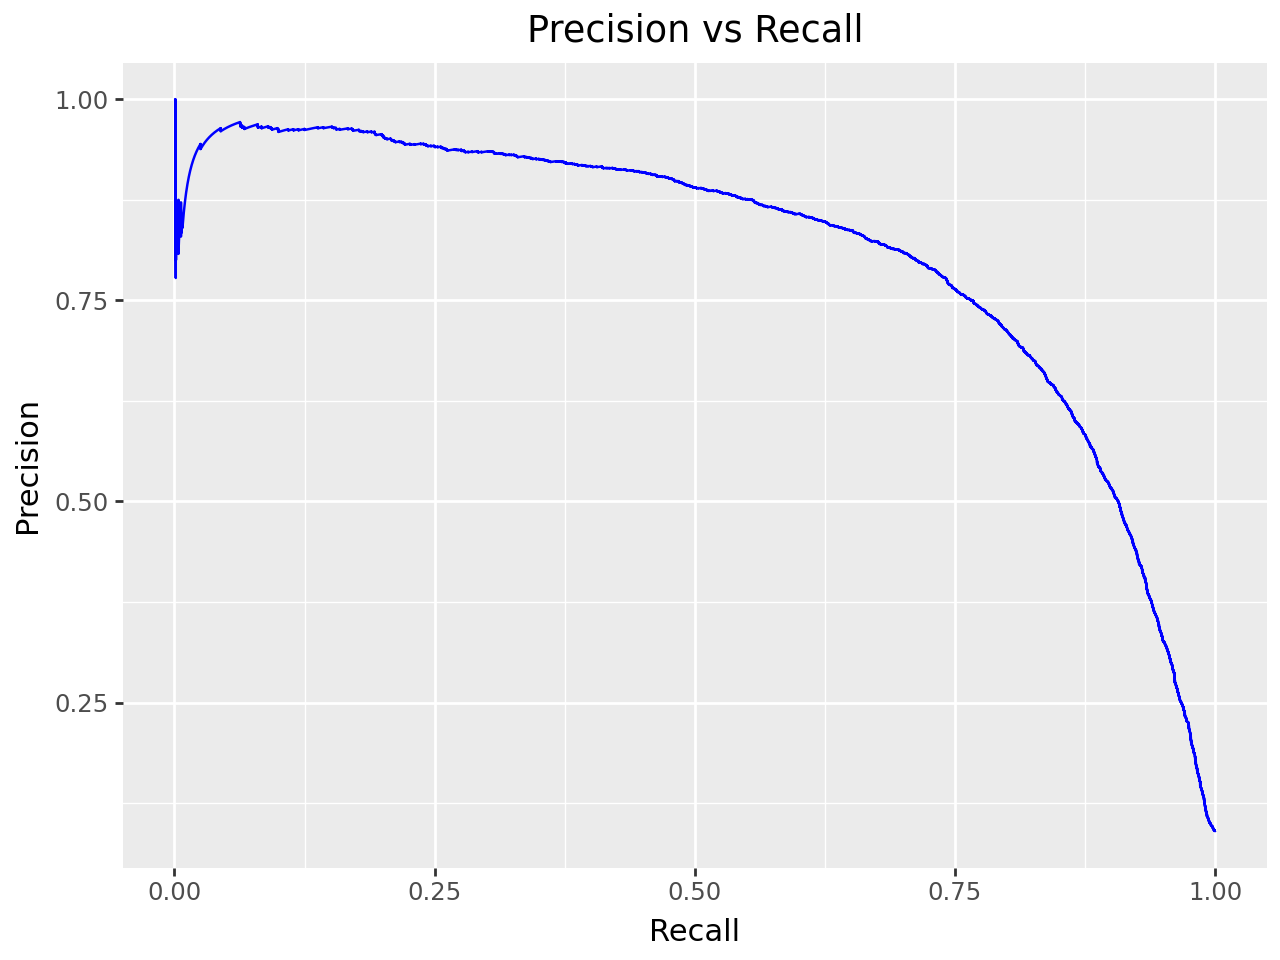

In [ ]:
# Otro grafico con la ys de presicion y recall, pero con el eje x como recall
(
    ggplot(
        data=pd.DataFrame({
            'thresholds': thresholds,
            'precisions': precisions[:-1],
            'recalls': recalls[:-1]
        })
    )
    + geom_line(aes(x='recalls', y='precisions'), color='blue')
    + labs(
        x='Recall',
        y='Precision',
        title='Precision vs Recall'
    )
)

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

#precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)

f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_precision = precisions[best_index]
best_recall = recalls[best_index]

print("Best threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1:", f1_scores[best_index])

Best threshold: -1991.7400221488995
Precision: 0.7780360255665311
Recall: 0.7410071942446043
F1: 0.7590702947840807


In [ ]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision 

np.float64(3370.0194991439557)

In [ ]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [ ]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

## The ROC Curve

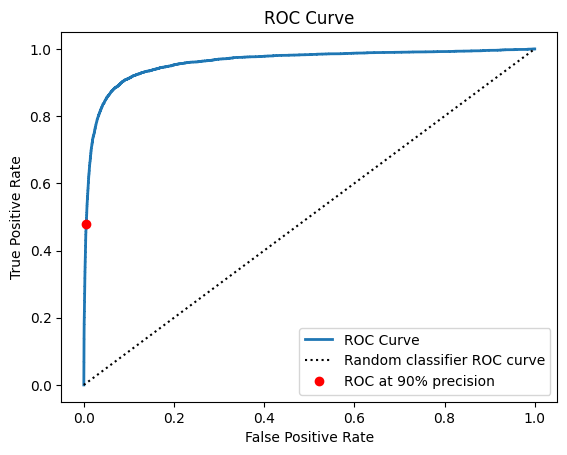

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k:', label='Random classifier ROC curve')
plt.plot(fpr_90, tpr_90, 'ro', label='ROC at 90% precision')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

Se usa ROC-AUC cuando el balanceo de clases es bueno, mientras que Precision-Recall es mejor para clases desbalanceadas. En MNIST, el “5” es una clase minoritaria, por lo que Precision-Recall es más informativo.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

In [ ]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba', n_jobs=-1)

In [ ]:
y_probas_forest[95:100]

array([[0.99, 0.01],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ]])

In [ ]:
y_prob_positive = y_probas_forest[:, 1] # Probabilidad de ser "FALTA"

# 2. Crear un DataFrame de Auditoría con Polars
df_audit = pl.DataFrame({
    "prob_estimada": y_prob_positive,
    "realidad": y_train
})

import polars as pl

# ... (tu código anterior de predicción)

# 3. Filtrar la "Zona de Duda"
zona_duda = df_audit.filter(
    (pl.col("prob_estimada") >= 0.4) & (pl.col("prob_estimada") <= 0.6)
)

total_casos = zona_duda.height

print(f"🔍 Auditoría en rango 40%-60%:")
print(f"Total de casos en este rango: {total_casos}")

if total_casos > 0:
    # EL FIX DEFINITIVO: Convertimos a Float64 antes de calcular el promedio
    # Esto convierte True -> 1.0 y False -> 0.0
    prob_real_en_zona = zona_duda.select(
        pl.col("realidad").cast(pl.Float64).mean()
    ).item() # .item() extrae el valor puro del DataFrame de resultado
    
    print(f"Probabilidad real observada: {prob_real_en_zona / total_casos * 100:.2%}")
else:
    print("Probabilidad real observada: N/A (Sin datos en este rango)")

🔍 Auditoría en rango 40%-60%:
Total de casos en este rango: 808
Probabilidad real observada: 62.75%


In [ ]:
# Asegúrate de usar .mean() y no .sum()
prob_real = zona_duda.select(pl.col("realidad").cast(pl.Float64)).mean().item()
print(f"Probabilidad real corregida: {prob_real:.2%}")

Probabilidad real corregida: 507.05%


## `from sklearn.calibration import CalibratedClassifierCV`

`CalibratedClassifierCV` se usa para **calibrar probabilidades** de un clasificador.  
En lugar de solo predecir bien la clase, busca que el valor de probabilidad sea **confiable**.

---

### ¿Qué problema resuelve?

Muchos modelos (por ejemplo, `RandomForestClassifier`) pueden dar probabilidades mal calibradas:

- predicen `0.80`, pero en realidad solo aciertan ~`0.65` de las veces;
- o predicen `0.20`, pero en realidad ocurre ~`0.35`.

Con calibración, queremos que:

- entre los casos con probabilidad ~`0.70`, aproximadamente el **70%** sean positivos.

---

### ¿Cómo funciona?

`CalibratedClassifierCV`:

1. entrena el modelo base en folds de validación cruzada,
2. aprende una transformación de sus scores/probabilidades,
3. devuelve probabilidades ajustadas (`predict_proba`) más realistas.

Esto ayuda mucho cuando tomas decisiones con umbrales (ej. 0.4–0.6).

---

### Parámetros clave

- `estimator`: modelo base a calibrar (ej. `RandomForestClassifier`).
- `method`:
    - `"sigmoid"`: Platt scaling (simple, robusto, suele funcionar bien).
    - `"isotonic"`: más flexible, pero puede sobreajustar con pocos datos.
- `cv`: número de folds para calibración interna.

In [ ]:

from sklearn.calibration import CalibratedClassifierCV


# 1. Definir el bosque base
forest_clf = RandomForestClassifier(random_state=42)

# 2. Aplicar Calibración
# 'sigmoid' (Platt Scaling) es excelente para corregir el sesgo que vimos
calibrated_clf = CalibratedClassifierCV(forest_clf, method='sigmoid', cv=3)

# 3. Entrenar (esto hace CV interna para no "hacer trampa")
calibrated_clf.fit(X_train, y_train_5)

# 4. Obtener las nuevas probabilidades "honestas"
y_probas_calib_oof = cross_val_predict(
    calibrated_clf, 
    X_train, 
    y_train_5, 
    cv=3, 
    method='predict_proba', 
    n_jobs=-1
)[:, 1]

# 2. Construir DataFrame de Auditoría Final
df_audit_final = pl.DataFrame({
    "prob_estimada": y_probas_calib_oof,
    "realidad": y_train_5
})

# 3. Filtrar zona crítica (40%-60%)
zona_duda_final = df_audit_final.filter(
    (pl.col("prob_estimada") >= 0.4) & (pl.col("prob_estimada") <= 0.6)
)

print(f"📊 Auditoría BLINDADA (Cross-Val-Predict) 40%-60%:")
print(f"Total de casos: {zona_duda_final.height}")

if zona_duda_final.height > 0:
    # Calculamos métricas con casting explícito para evitar errores de tipo
    prob_real = zona_duda_final.select(pl.col("realidad").cast(pl.Float64).mean()).item()
    prob_estimada_avg = zona_duda_final["prob_estimada"].mean()
    
    print(f"Probabilidad ESTIMADA media: {prob_estimada_avg:.2%}")
    print(f"Probabilidad REAL observada: {prob_real:.2%}")
    print(f"Error Residual: {abs(prob_estimada_avg - prob_real):.4f}")
else:
    print("N/A: El modelo no tuvo dudas en este rango durante la validación cruzada.")

📊 Auditoría BLINDADA (Cross-Val-Predict) 40%-60%:
Total de casos: 218
Probabilidad ESTIMADA media: 49.98%
Probabilidad REAL observada: 54.59%
Error Residual: 0.0460


In [ ]:
zona_duda_final.head()

prob_estimada,realidad
f64,bool
0.561462,true
0.576574,true
0.51911,true
0.458458,false
0.426177,true


In [ ]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
y_train_5, y_scores_forest)

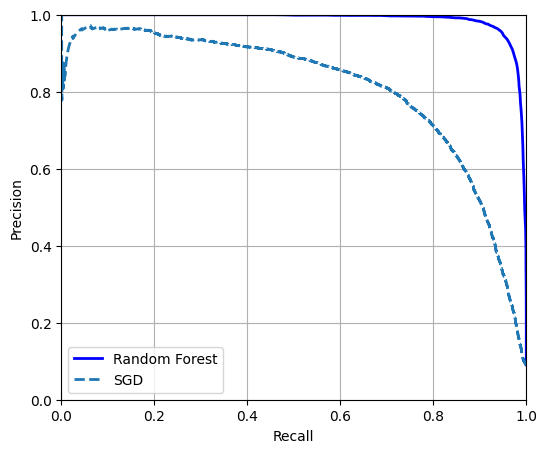

In [ ]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [ ]:
y_train_pred_forest = y_probas_calib_oof >= 0.5
f1_score(y_train_5, y_train_pred_forest)

0.9468344918279166

In [ ]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [ ]:
precision_score(y_train_5, y_train_pred_forest)

0.9645933014354067

In [ ]:
recall_score(y_train_5, y_train_pred_forest)

0.9297177642501383

Ya sabes cómo abordar la clasificación binaria. En resumen:

1. **Entrenar** clasificadores binarios.
2. **Elegir** la métrica adecuada según el objetivo.
3. **Evaluar** con validación cruzada.
4. **Ajustar** el equilibrio entre *precision* y *recall* según tu caso.
5. **Comparar** modelos con métricas y curvas (PR, ROC, AUC).

## Multiclass Classification

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000]) # y_train, not y_train_5

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


scikit-learn maneja clasificación multiclase con estrategias como:
- **One-vs-All (OvA)**: un clasificador por clase vs el resto.
- **One-vs-One (OvO)**: un clasificador para cada par de clases.

para clasificar con svm usa OvO.

In [ ]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [ ]:
# extra code – shows how to get all 45 OvO scores if needed
svm_clf.decision_function_shape = "ovo"
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 0.11, -0.21, -0.97,  0.51, -1.01,  0.19,  0.09, -0.31, -0.04,
        -0.45, -1.28,  0.25, -1.01, -0.13, -0.32, -0.9 , -0.36, -0.93,
         0.79, -1.  ,  0.45,  0.24, -0.24,  0.25,  1.54, -0.77,  1.11,
         1.13,  1.04,  1.2 , -1.42, -0.53, -0.45, -0.99, -0.95,  1.21,
         1.  ,  1.  ,  1.08, -0.02, -0.67, -0.14, -0.3 , -0.13,  0.25]])

In [ ]:
class_id = np.argmax(some_digit_scores)
class_id

np.int64(5)

In [ ]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000]) # y

ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [ ]:
len(ovr_clf.estimators_)

10

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [ ]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.87365, 0.85835, 0.8689 ])

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.8983, 0.891 , 0.9018])

## Error Analysis

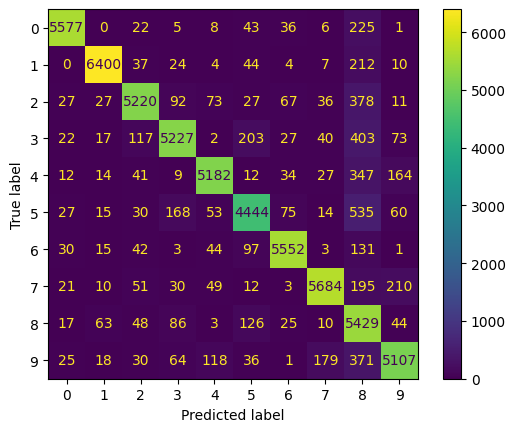

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3, n_jobs=-1)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

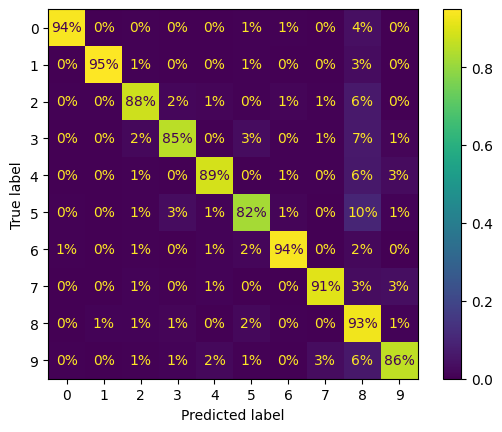

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
normalize="true", values_format=".0%")
plt.show()

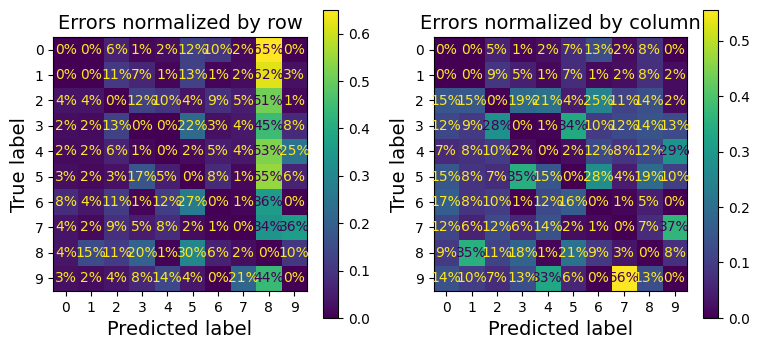

In [ ]:
sample_weight = (y_train_pred != y_train)

# extra code – this cell generates Figure 3–10
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")

plt.show()
plt.rc('font', size=14)  # make fonts great again

In [ ]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

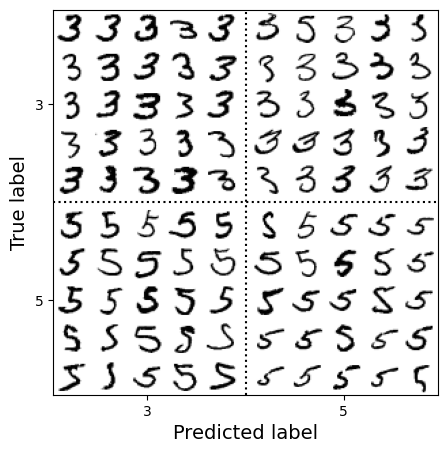

In [ ]:
# extra code – this cell generates Figure 3–11
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

## Multilabel Classification

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype(np.int64) % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3, n_jobs=-1)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [ ]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(KNeighborsClassifier(), random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000]) # reduce for speed
chain_clf.predict([some_digit])

array([[0., 1.]])

## Multioutput Classification

In [ ]:
rng = np.random.default_rng(seed=42)
noise_train = rng.integers(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise_train
noise_test = rng.integers(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test
y_train_mod = X_train
y_test_mod = X_test

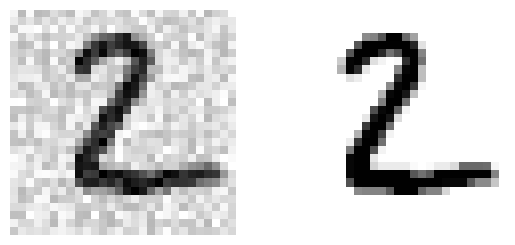

In [ ]:
# extra code – this cell generates Figure 3–12
plt.subplot(121); plot_digit(X_test_mod[1])
plt.subplot(122); plot_digit(y_test_mod[1])

plt.show()

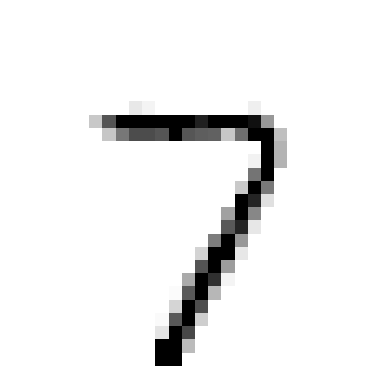

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit[0])
plt.show()

# Exercise solutions

## 1. An MNIST Classifier With Over 97% Accuracy

Exercise: _Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set. Hint: the `KNeighborsClassifier` works quite well for this task; you just need to find good hyperparameter values (try a grid search on the `weights` and `n_neighbors` hyperparameters)._

Let's start with a simple K-Nearest Neighbors classifier and measure its performance on the test set. This will be our baseline:

In [ ]:
from sklearn.metrics import accuracy_score

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
train_preds = knn_clf.predict(X_test)
accuracy_score(y_test, train_preds)

0.9688

Nice, a regular KNN can score 96.88% of accuracy let's fit some kind of hiperparameters

In [ ]:
from scipy.stats import randint

param_distribs = {
    'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]
}

grid_search = GridSearchCV(knn_clf, param_distribs, cv=5, n_jobs=-2)
grid_search.fit(X_train[:10000], y_train[:10000])
grid_search.best_params_


{'n_neighbors': 4, 'weights': 'distance'}

In [ ]:
grid_search.best_score_

np.float64(0.9441999999999998)

In [ ]:
knn_clf = grid_search.best_estimator_
knn_clf.fit(X_train, y_train)
tuned_accuracy = accuracy_score(y_test, knn_clf.predict(X_test))

## 2. Data Augmentation

Exercise: _Write a function that can shift an MNIST image in any direction (left, right, up, or down) by one pixel. You can use the `shift()` function from the `scipy.ndimage` module. For example, `shift(image, [2, 1], cval=0)` shifts the image two pixels down and one pixel to the right. Then, for each image in the training set, create four shifted copies (one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set. You should observe that your model performs even better now! This technique of artificially growing the training set is called _data augmentation_ or _training set expansion_._

Let's try augmenting the MNIST dataset by adding slightly shifted versions of each image.

In [ ]:
from scipy.ndimage import shift

In [ ]:
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    image = shift(image, [dy, dx], cval=0, mode="constant")

    return image.reshape([-1])

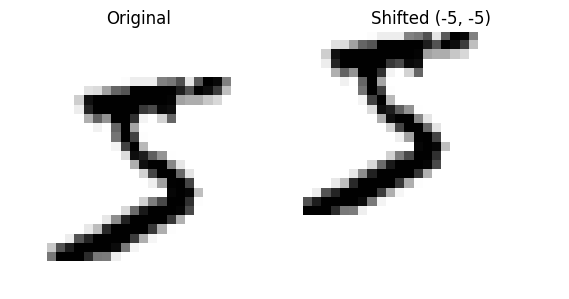

In [ ]:

# Imagen original y desplazada
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

# Original
axs[0].imshow(some_digit.reshape(28, 28), cmap='binary')
axs[0].set_title('Original')
axs[0].axis('off')

# Desplazada (-5, -5)
shifted = shift_image(some_digit, -5, -5)
axs[1].imshow(shifted.reshape(28, 28), cmap='binary')
axs[1].set_title('Shifted (-5, -5)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x_y_stacked = list(zip(X_train, y_train))
for image, label in zip(X_train, y_train):
    image_list = []
    image_list.append(shift_image(image, -1, 0))
    image_list.append(shift_image(image, 0, -1))
    image_list.append(shift_image(image, 1, 0))
    image_list.append(shift_image(image, 0, 1))

    for img in image_list:
        x_y_stacked.append((img, label))

In [ ]:
X_train_augmented = [x[0] for x in x_y_stacked]
y_train_augmented = [x[1] for x in x_y_stacked]

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [ ]:
rng = np.random.default_rng(seed=42)
shuffle_idx = rng.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [ ]:
knn_clf = grid_search.best_estimator_
knn_clf.fit(X_train_augmented, y_train_augmented)
augmented_accuracy = accuracy_score(y_test, knn_clf.predict(X_test))

By simply augmenting the data, we've got a 0.5% accuracy boost. Perhaps it does not sound so impressive, but it actually means that the error rate dropped significantly:

In [ ]:
error_rate_change = (1 - augmented_accuracy) / (1 - tuned_accuracy) - 1
print(f"error_rate_change = {error_rate_change:.0%}")

error_rate_change = -17%


The error rate dropped quite a bit thanks to data augmentation.

## 3. Tackle the Titanic dataset

Exercise: _Tackle the Titanic dataset. A great place to start is on [Kaggle](https://www.kaggle.com/c/titanic). Alternatively, you can download the data from https://homl.info/titanic.tgz and unzip this tarball like you did for the housing data in Chapter 2. This will give you two CSV files: _train.csv_ and _test.csv_ which you can load using `pandas.read_csv()`. The goal is to train a classifier that can predict the `Survived` column based on the other columns._

In [154]:
from pathlib import Path
import polars as pl
import tarfile
import urllib.request

def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets", filter="data")
    return [pl.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

In [155]:
train_data, test_data = load_titanic_data()
train_data = train_data.drop(pl.col(["PassengerId", "Name"]))
test_data = test_data.drop(pl.col(["PassengerId", "Name"]))

In [156]:
train_data.head()

Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,str,f64,i64,i64,str,f64,str,str
0,3,"""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
1,1,"""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
1,3,"""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
1,1,"""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
0,3,"""male""",35.0,0,0,"""373450""",8.05,null,"""S"""


In [157]:
train_data.to_pandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    object 
 9   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


In [158]:
import polars.selectors as cs

cat_cols = train_data.select(cs.string()).columns
num_cols = train_data.select(cs.numeric()).columns

Vamos a observar algunos estadisticos del dataset para entenderlo mejor:

In [159]:

train_data.with_columns(
    pl.when(pl.col("Sex") == "male").then(1).otherwise(0).alias("Sex")
).select(cs.numeric()).describe()

statistic,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
str,f64,f64,f64,f64,f64,f64,f64
"""count""",891.0,891.0,891.0,714.0,891.0,891.0,891.0
"""null_count""",0.0,0.0,0.0,177.0,0.0,0.0,0.0
"""mean""",0.383838,2.308642,0.647587,29.699113,0.523008,0.381594,32.204208
"""std""",0.486592,0.836071,0.47799,14.526507,1.102743,0.806057,49.693429
"""min""",0.0,1.0,0.0,0.4167,0.0,0.0,0.0
"""25%""",0.0,2.0,0.0,20.0,0.0,0.0,7.925
"""50%""",0.0,3.0,1.0,28.0,0.0,0.0,14.4542
"""75%""",1.0,3.0,1.0,38.0,1.0,0.0,31.0
"""max""",1.0,3.0,1.0,80.0,8.0,6.0,512.3292


Por lo visto solo el **38%** de las personas sobrevivieron al desastre, y en promedio tenían alrededor de 29 años. También se puede ver que existe 177 nulos en la edad.

El 75% de los pasajeros eran personas que estaba en 3ra clase, menos del 25% estaban en 1ra o 2da clase. 

La mayoría de los pasajeros eran hombres con un 64.76%, y el 35.24% eran mujeres.

También se puede observar que el 75% de los pasajeros pagaron menos de 31 dólares por su pasaje, lo que sugiere que la mayoría de los pasajeros eran de clase baja o media, el maximo pagador fue de 512 dolares, lo que indica que había algunos pasajeros de clase alta a bordo.

Como siguiente paso vermeos algunas correlacones entre las variables para entender mejor el dataset:

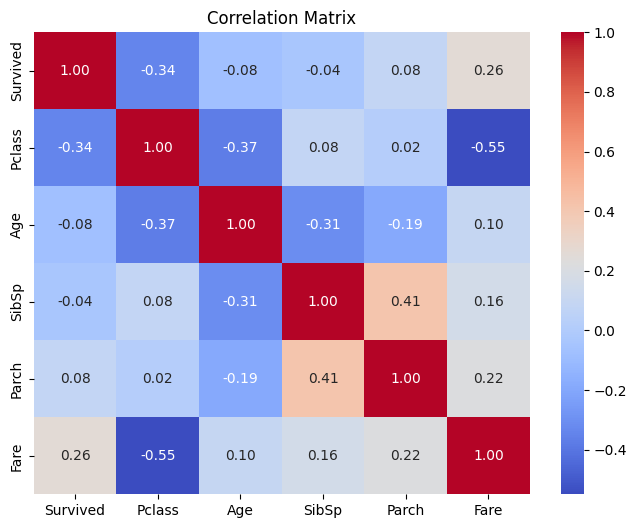

In [160]:
# Plot Corr

plt.figure(figsize=(8, 6))
sns.heatmap(train_data.select(cs.numeric()).to_pandas().corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [161]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, StandardScaler,
                                    MinMaxScaler, FunctionTransformer, PowerTransformer)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import (ColumnTransformer, TransformedTargetRegressor,
                              make_column_selector, make_column_transformer)

In [165]:

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)
cat_pipeline = Pipeline([
        ("ordinal_encoder", OrdinalEncoder()),
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("cat_encoder", OneHotEncoder(sparse_output=False)),
])


num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

preprocess_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ])

In [175]:
X_train = train_data.drop("Survived").to_pandas()
y_train = train_data["Survived"].to_pandas()

X_train = preprocess_pipeline.fit_transform(X_train)

In [176]:
random_forest_clf = RandomForestClassifier(random_state=42)
random_forest_clf.fit(X_train, y_train)
y_pred = random_forest_clf.predict(X_train)

accuracy = accuracy_score(y_train, y_pred)
print(f"Test set accuracy: {accuracy:.2%}")

Test set accuracy: 97.98%


In [177]:
forest_scores = cross_val_score(random_forest_clf, X_train, y_train, cv=10)
forest_scores.mean()

np.float64(0.8092759051186018)

Okay, not too bad! Looking at the [leaderboard](https://www.kaggle.com/c/titanic/leaderboard) for the Titanic competition on Kaggle, you can see that our score is in the top 2%, woohoo! Some Kagglers reached 100% accuracy, but since you can easily find the [list of victims](https://www.encyclopedia-titanica.org/titanic-victims/) of the Titanic, it seems likely that there was little Machine Learning involved in their performance! 😆

Let's try an `SVC`:

In [178]:
from sklearn.svm import SVC

svm_clf = SVC(gamma="auto")
svm_scores = cross_val_score(svm_clf, X_train, y_train, cv=10)
svm_scores.mean()

np.float64(0.8249313358302123)

Great! This model looks better.

But instead of just looking at the mean accuracy across the 10 cross-validation folds, let's plot all 10 scores for each model, along with a box plot highlighting the lower and upper quartiles, and "whiskers" showing the extent of the scores (thanks to Nevin Yilmaz for suggesting this visualization). Note that the `boxplot()` function detects outliers (called "fliers") and does not include them within the whiskers. Specifically, if the lower quartile is $Q_1$ and the upper quartile is $Q_3$, then the interquartile range $IQR = Q_3 - Q_1$ (this is the box's height), and any score lower than $Q_1 - 1.5 \times IQR$ is a flier, and so is any score greater than $Q3 + 1.5 \times IQR$.

C:\Users\sergi\AppData\Local\Temp\ipykernel_11436\3995193800.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([svm_scores, forest_scores], labels=("SVM", "Random Forest"))


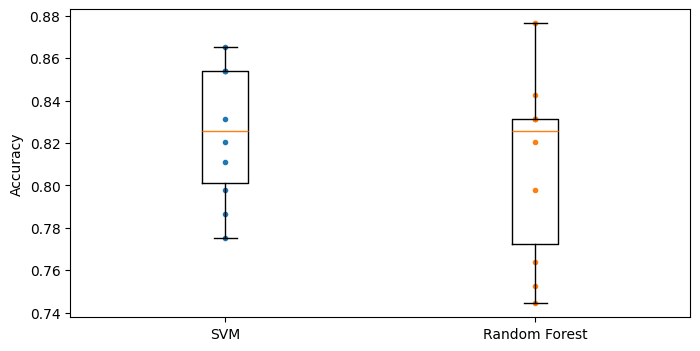

In [179]:
plt.figure(figsize=(8, 4))
plt.plot([1]*10, svm_scores, ".")
plt.plot([2]*10, forest_scores, ".")
plt.boxplot([svm_scores, forest_scores], labels=("SVM", "Random Forest"))
plt.ylabel("Accuracy")
plt.show()

## 4. Spam classifier

Exercise: _Build a spam classifier (a more challenging exercise):_

* _Download examples of spam and ham from [Apache SpamAssassin's public datasets](https://homl.info/spamassassin)._
* _Unzip the datasets and familiarize yourself with the data format._
* _Split the datasets into a training set and a test set._
* _Write a data preparation pipeline to convert each email into a feature vector. Your preparation pipeline should transform an email into a (sparse) vector that indicates the presence or absence of each possible word. For example, if all emails only ever contain four words, "Hello," "how," "are," "you," then the email "Hello you Hello Hello you" would be converted into a vector [1, 0, 0, 1] (meaning [“Hello" is present, "how" is absent, "are" is absent, "you" is present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of each word._

_You may want to add hyperparameters to your preparation pipeline to control whether or not to strip off email headers, convert each email to lowercase, remove punctuation, replace all URLs with "URL," replace all numbers with "NUMBER," or even perform _stemming_ (i.e., trim off word endings; there are Python libraries available to do this)._

_Finally, try out several classifiers and see if you can build a great spam classifier, with both high recall and high precision._

In [95]:
import tarfile
import urllib.request

def fetch_spam_data():
    spam_root = "http://spamassassin.apache.org/old/publiccorpus/"
    ham_url = spam_root + "20030228_easy_ham.tar.bz2"
    spam_url = spam_root + "20030228_spam.tar.bz2"

    spam_path = Path() / "datasets" / "spam"
    spam_path.mkdir(parents=True, exist_ok=True)
    for dir_name, tar_name, url in (("easy_ham", "ham", ham_url),
                                    ("spam", "spam", spam_url)):
        if not (spam_path / dir_name).is_dir():
            path = (spam_path / tar_name).with_suffix(".tar.bz2")
            print("Downloading", path)
            urllib.request.urlretrieve(url, path)
            tar_bz2_file = tarfile.open(path)
            tar_bz2_file.extractall(path=spam_path, filter="data")
            tar_bz2_file.close()
    return [spam_path / dir_name for dir_name in ("easy_ham", "spam")]

In [96]:
ham_dir, spam_dir = fetch_spam_data()

Next, let's load all the emails:

In [97]:
ham_filenames = [f for f in sorted(ham_dir.iterdir()) if len(f.name) > 20]
spam_filenames = [f for f in sorted(spam_dir.iterdir()) if len(f.name) > 20]

In [98]:
len(ham_filenames)

2500

In [99]:
len(spam_filenames)

500

We can use Python's `email` module to parse these emails (this handles headers, encoding, and so on):

In [100]:
import email
import email.policy

def load_email(filepath):
    with open(filepath, "rb") as f:
        return email.parser.BytesParser(policy=email.policy.default).parse(f)

In [101]:
ham_emails = [load_email(filepath) for filepath in ham_filenames]
spam_emails = [load_email(filepath) for filepath in spam_filenames]

In [102]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array(ham_emails + spam_emails, dtype=object)
y = np.array([0] * len(ham_emails) + [1] * len(spam_emails))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

Let's look at one example of ham and one example of spam, to get a feel of what the data looks like:

In [103]:
print(ham_emails[0].get_content().strip())

Date:        Wed, 21 Aug 2002 10:54:46 -0500
    From:        Chris Garrigues <cwg-dated-1030377287.06fa6d@DeepEddy.Com>
    Message-ID:  <1029945287.4797.TMDA@deepeddy.vircio.com>


  | I can't reproduce this error.

For me it is very repeatable... (like every time, without fail).

This is the debug log of the pick happening ...

18:19:03 Pick_It {exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace} {4852-4852 -sequence mercury}
18:19:03 exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace 4852-4852 -sequence mercury
18:19:04 Ftoc_PickMsgs {{1 hit}}
18:19:04 Marking 1 hits
18:19:04 tkerror: syntax error in expression "int ...

Note, if I run the pick command by hand ...

delta$ pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace  4852-4852 -sequence mercury
1 hit

That's where the "1 hit" comes from (obviously).  The version of nmh I'm
using is ...

delta$ pick -version
pick -- nmh-1.0.4 [compiled on fuchsia.cs.mu.OZ.AU at Sun Mar 17 14:55:56 

In [104]:
import contractions
import re

text = ham_emails[0].get_content().strip()

In [105]:
import spacy

spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")

doc = nlp(text)
words = [token.text for token in doc if token.is_alpha or token.text == "'" or token.is_digit]
print(words)
# Output: ['That', 's', 'amazing', 'Really', 'isn', 't']

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
['Date', 'We', 'd', '21', 'Aug', '2002', 'From', 'Chris', 'Garrigues', 'cwg', 'Com', 'Message', 'ID', 'I', 'ca', 'reproduce', 'this', 'error', 'For', 'me', 'it', 'is', 'very', 'repeatable', 'like', 'every', 'time', 'without', 'fail', 'This', 'is', 'the', 'debug', 'log', 'of', 'the', 'pick', 'happening', 'exec', 'pick', 'inbox', 'ftp', '4852', '4852', 'mercury', 'exec', 'pick', 'inbox', 'ftp', '4852', '4852', 'mercury', '1', 'hit', 'Marking', '1', 'hits', 'tkerror', 'syntax', 'error', 'in', 'expression', 'int', 'Note', 'if', 'I', 'run', 'the', 'pick', 'command', 'by', 'hand', 'pick', 'inbox', 'ftp', '4852', '4852', 'mercury', '1', 'hit', 'That', 'where', 't

In [106]:
from sklearn.base import BaseEstimator, TransformerMixin, MetaEstimatorMixin
from bs4 import BeautifulSoup

class EmailToWordTokenizer(BaseEstimator, TransformerMixin):
    def __init__(self, with_lemma=True, replace_urls=True, replace_emails=True, remove_html=True):
        self.with_lemma = with_lemma
        self.replace_urls = replace_urls
        self.replace_emails = replace_emails
        self.remove_html = remove_html

    def fit(self, X, y=None):
        return self

    
    def transform(self, X):
        X_cleaned = []
        for email in X:
            # --- NUEVA LÓGICA DE EXTRACCIÓN ---
            text = ""
            # .walk() recorre todas las partes del correo (texto, html, firmas, adjuntos)
            for part in email.walk():
                ctype = part.get_content_type()
                # Solo nos interesa lo que sea texto plano
                if ctype == "text/plain":
                    try:
                        text += part.get_content()
                    except:
                        # Si falla el content manager, sacamos el payload crudo
                        text += str(part.get_payload(decode=True))
            
            # Si de plano no había text/plain (tal vez solo era HTML)
            if not text:
                text = "[Empty Email or non-text format]"
            # ----------------------------------

            # Ahora sí, aplicas tus limpiezas sobre la variable 'text'
            text = text.strip()
            if self.replace_emails:
                text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' EMAIL_TOKEN ', text)

            if self.replace_emails:
                text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' EMAIL_TOKEN ', text)
            if self.replace_urls:
                text = re.sub(r'https?://\S+|www\.\S+', ' URL_TOKEN ', text)

            text = re.sub(r'\d+(?:\.\d*(?:[eE]\d+))?', ' NUMBER_TOKEN ', text)
            
            # lemmatización
            if self.with_lemma:
                # Pasamos el texto a minúsculas y se lo damos a spaCy
                doc = nlp(text.lower())
                # Filtramos signos de puntuación y espacios, y nos quedamos con el lema
                tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
                text = " ".join(tokens)
                
            X_cleaned.append(text)
                
        return X_cleaned


In [107]:
# pipeline con pipeline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

preprocess_pipeline = Pipeline([
    ("email_to_words", EmailToWordTokenizer()),
    ("count_vectorizer", CountVectorizer())
])

In [108]:
text_processed = preprocess_pipeline.fit_transform(X_train)
text_processed.shape

(2400, 30648)

In [109]:
text_processed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 243950 stored elements and shape (2400, 30648)>

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_clf = LogisticRegression(max_iter=1000, random_state=42)
score = cross_val_score(log_clf, text_processed, y_train, cv=3)
score.mean()

np.float64(0.9891666666666667)

In [113]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = preprocess_pipeline.transform(X_test)

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(text_processed, y_train)

y_pred = log_clf.predict(X_test_transformed)

print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")

Precision: 97.92%
Recall: 98.95%
